# ClearPath DQR + Cleaning Pipeline

**Data Source**: Docker MySQL `clearpath` (loaded by `database_build.ipynb`)

**Structure**: Executive Summary → Data Profiling → Quality Dimensions → Anomaly Detection → DQ Score → Cleaning Pipeline → Action Items → Appendix

**Target ML**: Busyness prediction (time series + user reports)

---
## Part 0: Configuration & DB Connection

In [12]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Paths (absolute — kernel cwd is project root)
PROJECT_ROOT = Path('/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project')
TEST_ROOT = PROJECT_ROOT / 'Data+ML' / 'test'
OUTPUT_DIR = TEST_ROOT / '6.8-6.12_DB' / 'tests' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(TEST_ROOT))

# ── 精简后只有 3 个模块 ──
DQR_TABLES = (
    'venues', 'restroom_profiles', 'healthcare_profiles', 'emergency_assets',
    'pedestrian_ramps', 'venue_source_links', 'busyness_scores',
    'external_context_cache', 'user_reports',
)

from dqr.dqr_checks import (
    DQ_WEIGHTS,
    check_completeness, check_accuracy, check_database_integrity, check_fk_orphans,
    compute_dq_scores, compute_total_score,
    build_all_profiles, build_record_analysis,
    detect_coordinate_anomalies, detect_gps_duplicates,
    clean_venues, build_action_items, assess_ml_usability,
)
from dqr.dqr_utils import (
    MANHATTAN_BOUNDS, get_conn, is_manhattan, validate_coords, gps_to_district,
    fetch_traffic_hourly, clean_traffic, fetch_and_clean_weather,
)
from dqr.dqr_io import query_table, load_dqr_tables, export_dqr_artifacts, build_audit_report

print(f'Project: {PROJECT_ROOT}  |  Output: {OUTPUT_DIR}')
print(f'Started: {datetime.now():%Y-%m-%d %H:%M}')

Project: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project  |  Output: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.8-6.12_DB/tests/output
Started: 2026-06-13 10:26


---
## 1. Executive Summary

In [3]:
loaded = load_stage()

print(f'={"="*58}')
print('  EXECUTIVE SUMMARY — ClearPath DQR')
print('  数据库: clearpath (Docker MySQL)')
print(f'  总行数: {loaded.total_rows:,}  |  表加载: {loaded.tables_loaded}/{len(DQR_TABLES)}')
print(f'  场馆: {len(loaded.venues_df):,}  |  类型: {loaded.venue_type_distribution}')
print(f'  完整率: {loaded.completeness_pct:.1f}%  |  日期: {datetime.now():%Y-%m-%d}')
if loaded.load_errors:
    print(f'  可选表加载错误: {loaded.load_errors}')
print(f'={"="*58}')

/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_io.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


  EXECUTIVE SUMMARY — ClearPath DQR
  数据库: clearpath (Docker MySQL)
  总行数: 38,140  |  表加载: 7/9
  场馆: 4,838  |  类型: {'emergencyasset': 3279, 'healthcare': 1086, 'restroom': 473}
  完整率: 63.5%  |  日期: 2026-06-13


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_io.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


---
## 2. Data Profiling

In [4]:
analysis = analysis_stage(loaded.data)
print(f'Column profiling: {len(analysis.all_profiles)} fields across {loaded.tables_loaded} tables')

if not analysis.healthcare_profile.empty:
    display(analysis.healthcare_profile)

print(f'Event types: actual={analysis.event_types["actual"]}, '
      f'unknown={analysis.event_types["unknown"]}, missing={analysis.event_types["missing"]}')
print(analysis.row_stats.to_string(index=False))

if not analysis.record_analysis.empty:
    quality_values = analysis.record_analysis['record_quality_score']
    print(f'Record quality: mean={quality_values.mean():.2f}, min={quality_values.min():.2f}, '
          f'low(<0.5)={(quality_values < 0.5).sum()}')

Column profiling: 87 fields across 7 tables


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/dqr/dqr_analysis.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(frames, ignore_index=True)


,column,dtype,non_null,cardinality,top5,freq_%
0,venue_id,object,1086,1086,0006c1aef358bc9d07ac1a05258679fbfa71 | a6ff1fe...,0.1 | 0.1 | 0.1 | 0.1 | 0.1
1,facility_external_id,object,431,431,15615 | 15577 | 7066 | 10111 | 9173,0.2 | 0.2 | 0.2 | 0.2 | 0.2
5,operator_name,object,431,213,NYU Langone Hospitals | The New York and Presb...,6.7 | 5.3 | 4.2 | 3.7 | 3.0
4,healthcare_speciality,object,151,64,dermatology | plastic_surgery | gynaecology | ...,10.6 | 7.9 | 6.6 | 5.3 | 4.6
2,facility_type,object,1051,17,pharmacy | clinic | dentist | LHCSA | DTC-EC,27.0 | 23.4 | 9.1 | 8.4 | 7.6
6,ownership_type,object,431,6,Not for Profit Corporation | Business Corporat...,63.1 | 16.7 | 15.1 | 4.6 | 0.2
3,healthcare_category,object,1086,4,clinic | pharmacy | hospital | dentist,51.4 | 26.2 | 13.6 | 8.8
8,official_source_priority,int64,1086,2,2 | 1,60.3 | 39.7
7,main_site_name,object,0,0,,


Event types: actual=[], unknown=[], missing=['closed_early', 'elevator_broken', 'entrance_closed', 'large_crowd', 'protest_or_blockage', 'ramp_blocked', 'toilet_out_of_order', 'wheelchair_lift_broken']
                 table  rows  columns  duplicate_rows  null_cells  coordinate_outliers
                venues  4838       24               0       42436                  164
     restroom_profiles   473       10               0        2346                    0
   healthcare_profiles  1086        9               0        4021                    0
      emergency_assets  3279       10               0        2601                    0
      pedestrian_ramps 23625       17               0         235                   27
    venue_source_links  4838        9               0        1128                    0
external_context_cache     1        8               0           1                    0
Record quality: mean=1.00, min=0.83, low(<0.5)=0


---
## 3. Data Quality Dimensions

In [5]:
quality = quality_stage(loaded.data, loaded.venues_df)

for name in ['completeness', 'accuracy', 'consistency', 'uniqueness',
             'timeliness', 'validity', 'integrity', 'fk_orphans']:
    result = quality.checks[name]
    status = 'PASS' if result['passed'] else 'FAIL'
    issues = f'  issues={result["issues"]}' if result['issues'] else ''
    print(f'  {name:<15} score={result["score"]:>6.1f}  {status}{issues}')

print('\nCompleteness detail:')
print(quality.checks['completeness']['_dataframe'].to_string(index=False))

  completeness    score=  97.0  PASS
  accuracy        score= 100.0  PASS
  consistency     score=  79.2  FAIL  issues=['1004 records with borough != Manhattan']
  uniqueness      score= 100.0  PASS
  timeliness      score=  95.0  FAIL  issues=['1 expired cache entries']
  validity        score=   0.0  FAIL  issues=['3279 ENUM violations across tables']
  integrity       score=  97.4  FAIL  issues=['124 venues with null district', '124/124 have GPS (0,0)']
  fk_orphans      score= 100.0  PASS

Completeness detail:
              table               field  filled  total  completeness_pct
             venues            venue_id    4838   4838             100.0
             venues          venue_type    4838   4838             100.0
             venues                name    4838   4838             100.0
             venues            latitude    4838   4838             100.0
             venues           longitude    4838   4838             100.0
             venues            district   

---
## 4. Anomaly Detection

In [6]:
anomaly = anomaly_stage(loaded.data)
print(f'Anomalies: {len(anomaly.anomaly_df)}')
if not anomaly.anomaly_df.empty:
    print(anomaly.anomaly_df['type'].value_counts().to_string())

print(f'GPS duplicates (<30m): {len(anomaly.gps_duplicates_df)} pairs')
if not anomaly.gps_duplicates_df.empty:
    display(anomaly.gps_duplicates_df.head(5))

Grid pre-filter:   114,297,750 brute-force →       29,687 candidates (0.03%)
Execution time:  0.06s
Anomalies: 315
type
outside_manhattan    191
zero_coordinates     124
GPS duplicates (<30m): 9425 pairs


,table_a,id_a,name_a,table_b,id_b,name_b,distance_m
0,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,308926,308926,20.9
1,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,308927,308927,21.7
2,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,310450,310450,11.0
3,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,310432,310432,6.6
4,venues,0006c1aef358bc9d07ac1a05258679fbfa71,Columbia University Health Care Mobile Van,pedestrian_ramps,310448,310448,9.0


---
## 5. DQ Score & Rating

In [7]:
scoring = scoring_stage(loaded.data, loaded.venues_df, anomaly, quality.coord_valid_mask)

print('DQ SCORE & RATING')
print(f'{"Dimension":<18} {"Weight":>7} {"Score":>7} {"Weighted":>8}')
print('-' * 42)
for dimension in DQ_WEIGHTS:
    score = scoring.scores[dimension]
    print(f'{dimension:<18} {DQ_WEIGHTS[dimension]:>6.0%} {score:>7.1f} '
          f'{score * DQ_WEIGHTS[dimension]:>8.1f}')
print('-' * 42)
print(f'{"TOTAL":<18} {"100%":>7} {scoring.total_score:>7.1f}')
print(f'Rating: {scoring.grade} ({scoring.total_score:.1f}/100)')

DQ SCORE & RATING
Dimension           Weight   Score Weighted
------------------------------------------
Completeness          25%    99.6     24.9
Accuracy              25%    93.5     23.4
Consistency           15%    79.2     11.9
Uniqueness            15%    50.0      7.5
Timeliness            10%    95.0      9.5
Validity              10%    32.2      3.2
------------------------------------------
TOTAL                 100%    80.4
Rating: Good (80.4/100)


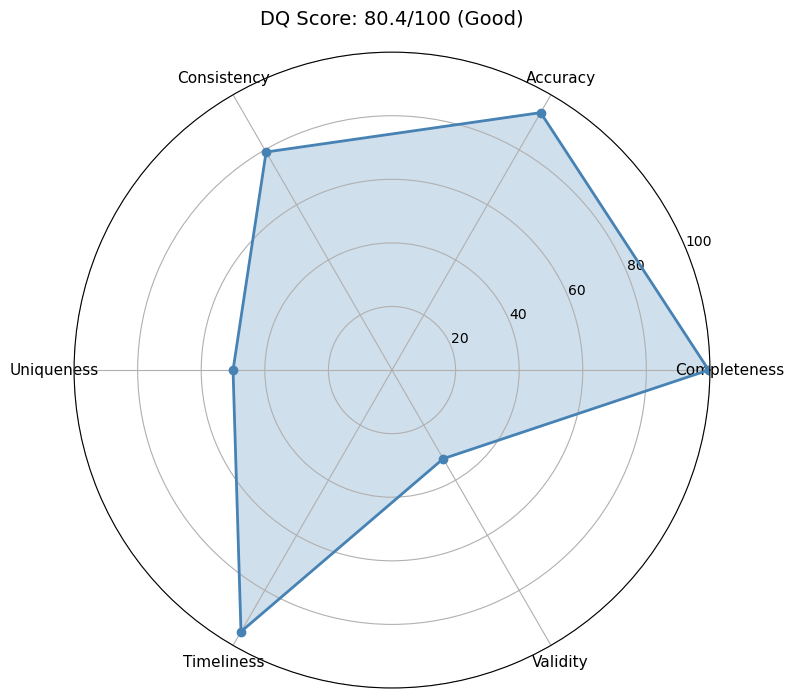

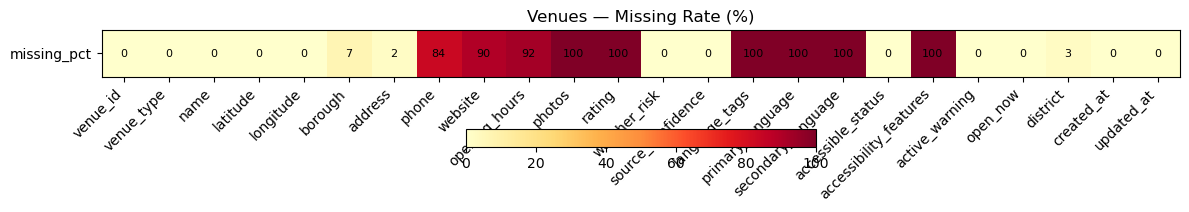

In [8]:
# Radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
dimensions = list(scoring.scores)
values = [scoring.scores[name] for name in dimensions]
angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]
ax.fill(angles, values_plot, alpha=0.25, color='steelblue')
ax.plot(angles, values_plot, 'o-', color='steelblue', linewidth=2)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(dimensions, size=11)
ax.set_ylim(0, 100)
ax.set_title(f'DQ Score: {scoring.total_score:.1f}/100 ({scoring.grade})', size=14, pad=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_dimension_scores.png', dpi=150); plt.show()

# Missing rate heatmap
venue_profile = analysis.all_profiles[analysis.all_profiles['table'] == 'venues'].copy()
if not venue_profile.empty:
    fig, ax = plt.subplots(figsize=(12, 2))
    missing_values = venue_profile['missing_pct'].to_numpy()[None, :]
    image = ax.imshow(missing_values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(venue_profile)), labels=venue_profile['column'], rotation=45, ha='right')
    ax.set_yticks([0], labels=['missing_pct'])
    for column_index, value in enumerate(missing_values[0]):
        ax.text(column_index, 0, f'{value:.0f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, orientation='horizontal', pad=0.45)
    ax.set_title('Venues — Missing Rate (%)')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_missing_heatmap.png', dpi=150); plt.show()

---
## 6. Cleaning Pipeline & External Data

  Coords: removed 0 invalid records (cached mask)
  Kept: 4838 records (quality_score mean=1.00)
venues_clean: 4838 records


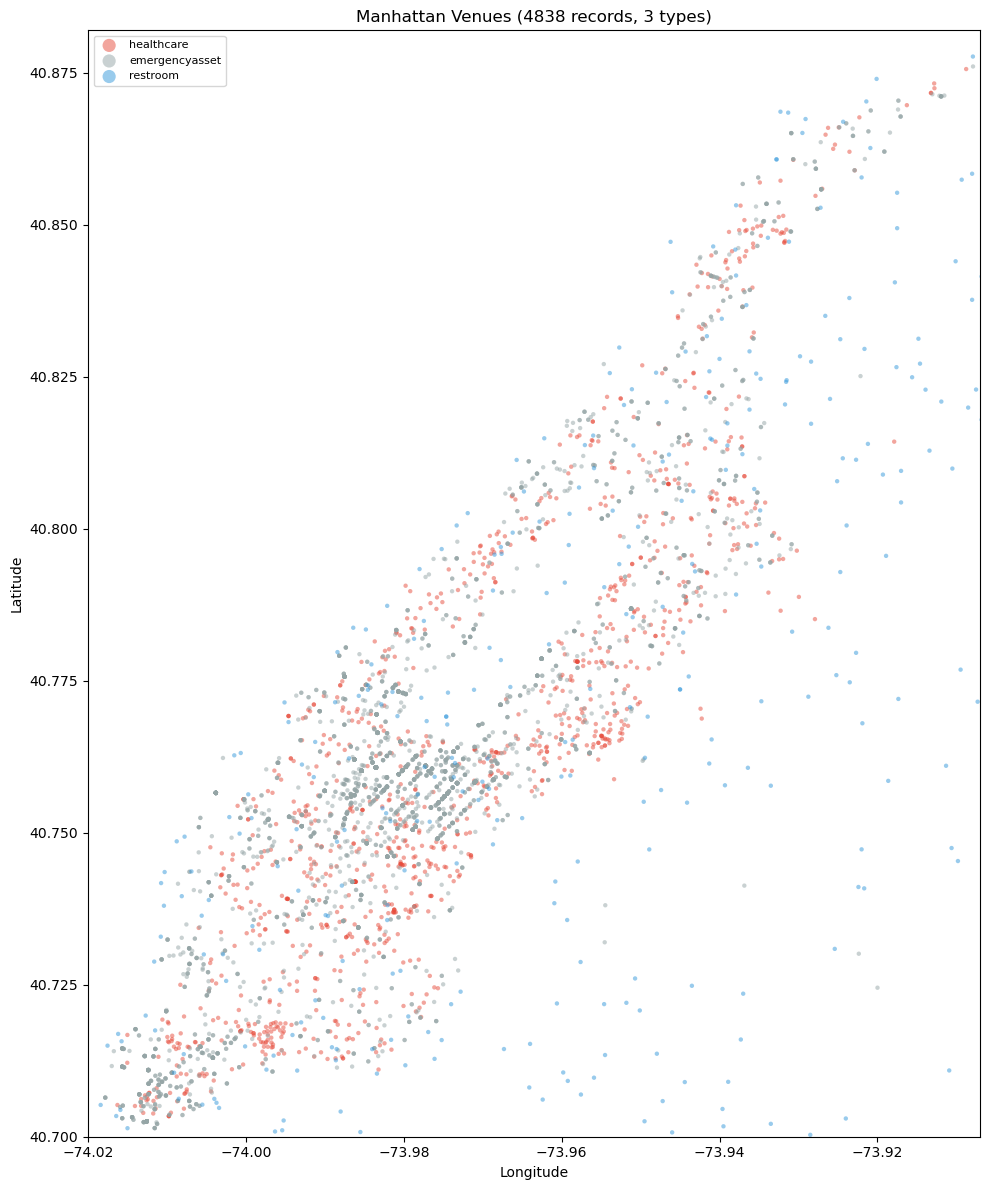

In [9]:
cleaning = cleaning_stage(loaded.venues_df, quality.coord_valid_mask, analysis.record_analysis)
print(f'venues_clean: {len(cleaning.venues_clean)} records')

if not cleaning.venues_clean.empty and 'latitude' in cleaning.venues_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = {'restroom': '#3498db', 'healthcare': '#e74c3c', 'emergency_asset': '#f39c12',
              'clinic': '#9b59b6', 'pharmacy': '#2ecc71', 'hospital': '#e91e63',
              'dentist': '#00bcd4', 'laboratory': '#795548'}
    for venue_type in cleaning.venues_clean['venue_type'].unique():
        subset = cleaning.venues_clean[cleaning.venues_clean['venue_type'] == venue_type]
        ax.scatter(subset['longitude'], subset['latitude'], c=colors.get(venue_type, '#95a5a6'),
                   label=venue_type, alpha=0.5, s=10, edgecolors='none')
    ax.set(xlabel='Longitude', ylabel='Latitude',
           title=f'Manhattan Venues ({len(cleaning.venues_clean)} records, '
                 f'{cleaning.venues_clean["venue_type"].nunique()} types)',
           xlim=(MANHATTAN_BOUNDS['lng_min'], MANHATTAN_BOUNDS['lng_max']),
           ylim=(MANHATTAN_BOUNDS['lat_min'], MANHATTAN_BOUNDS['lat_max']))
    ax.legend(fontsize=8, markerscale=3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_venue_scatter.png', dpi=150); plt.show()

In [10]:
external = external_stage(year=2025)
print(f'Traffic rows: {len(external.traffic_clean)} | Weather rows: {len(external.weather_clean)}')
if external.errors:
    print(f'External data warnings: {external.errors}')

Querying SODA API: boro=Manhattan, yr=2025...
  → 792 rows returned
Traffic cleaned: 792 rows, 28 segments
  Busyness distribution: {'busy': 357, 'moderate': 230, 'quiet': 205}
Weather: Mostly Cloudy, 21.7C, risk=low
Traffic rows: 792 | Weather rows: 1


---
## 7. Action Items & Appendix

In [11]:
final = finalize_stage(
    data=loaded.data, venues_df=loaded.venues_df, analysis=analysis,
    anomaly=anomaly, scoring=scoring, cleaning=cleaning, external=external,
    tables_loaded=loaded.tables_loaded, total_rows=loaded.total_rows,
    output_dir=OUTPUT_DIR,
)

print('=== Action Items ===')
display(final.actions_df)
ml = final.ml_usability
print(f'\n{"="*50}')
print(f'  ML USABILITY: {ml["venues_count"]} venues, {ml["coord_complete_pct"]:.0f}% coords, '
      f'{ml["district_count"]}/4 districts, DQ={ml["dq_score"]:.1f}/100')
print(f'{"="*50}')

venues_clean.csv               →  4,838 rows
traffic_hourly.csv             →    792 rows
weather_current.csv            →      1 rows
dqr_field_summary.csv          →     87 rows
dqr_record_analysis.csv        →  4,838 rows
dqr_outliers.csv               →    315 rows
dqr_gps_duplicates.csv         →  9,425 rows
            metric                      value
   dqr_total_score            80.4/100 (Good)
   tables_analyzed                          7
     total_records                      38140
      venues_total                       4838
      venues_clean                       4838
anomalies_detected                        315
    gps_duplicates                       9425
      action_items                          2
         timestamp 2026-06-13T10:25:10.414630

→ Saved: dqr_report.csv
=== Action Items ===


,priority,issue,recommendation,owner
0,P1,124 venues with null district,Apply gps_to_district() to fill missing districts,Data+ML
1,P1,1 expired cache entries,Refresh external_context_cache entries,Backend



  ML USABILITY: 4838 venues, 100% coords, 4/4 districts, DQ=80.4/100
